# Layer 2: The HP scaling law $\eta^\star(w,T)$

[Notebook 01](01_tune_one_cell.ipynb) found $\eta^\star$ for one cell. Brute-forcing it for
every $(N,D)$ in a full grid would be wasteful, but unnecessary, because $\eta^\star$ moves
*predictably*:

* **with width $w$**, $\eta^\star$ falls as the model gets wider (the μP shift);
* **with step budget $T=D/b$**, $\eta^\star$ falls as the horizon grows.

So we measure $\eta^\star$ on a handful of cells (each via the `tune_lr_cell` of notebook 01)
and fit a transfer law $\eta^\star(w,T)=\eta_{\rm ref}\,(w/w_{\rm ref})^{c_w}\,(T/T_{\rm ref})^{c_T}$.
The expensive measurement is done by [`run_hp_study.py`](../scripts/run_hp_study.py); here we
load its output and re-derive the fit.

In [1]:
import json
import numpy as np
from pathlib import Path
from IPython.display import Image

from scaling_laws.data import TeacherStudentRegression
from scaling_laws.live import measure_law_live
from scaling_laws.hp import fit_law_from_points
from scaling_laws import plotting as pl
pl.set_style()

RESULTS = Path("../results").resolve(); FIGDIR = RESULTS / "figures"
prob = TeacherStudentRegression(input_dim=32, teacher_width=256, teacher_depth=2,
                                teacher_act="gelu", noise_std=0.1, val_size=16384, seed=0)
study = json.load(open(RESULTS / "hp_study_cosine.json"))   # the full, precomputed calibration
print(f"full calibration: eta* at {len(study['widths'])} widths x {len(study['Tsteps'])} step budgets")

full calibration: eta* at 8 widths x 6 step budgets


## Measure it live

The law is just the **L1 sweep of [notebook 01](01_tune_one_cell.ipynb), repeated across cells**.
Run it here on a cheap subset, three widths (at a fixed short horizon) and three step budgets (at
fixed width). The **top** panels show each cell's LR sweep with the chosen $\eta^\star$ starred; the
**bottom** panels collect those $\eta^\star$ into the two power laws. The exponents won't match the
full calibration below exactly (few points, one seed), but the trends are already clear.

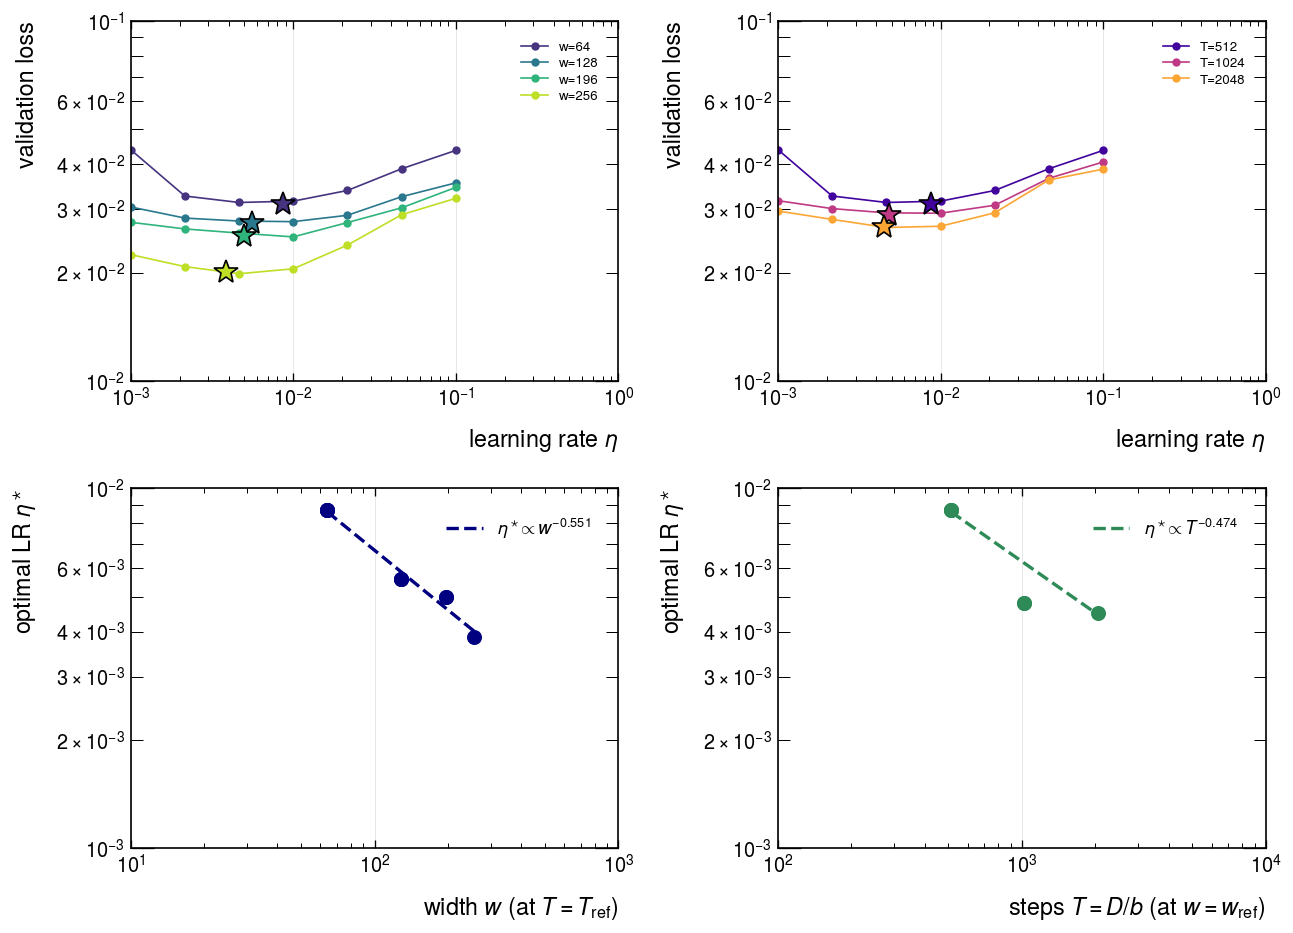

eta* vs width:   0%|          | 0/4 [00:00<?, ?w/s]

eta* vs width:  25%|██▌       | 1/4 [00:05<00:16,  5.38s/w]

eta* vs width:  50%|█████     | 2/4 [00:12<00:12,  6.27s/w]

eta* vs width:  75%|███████▌  | 3/4 [00:20<00:07,  7.36s/w]

eta* vs width: 100%|██████████| 4/4 [00:29<00:00,  7.75s/w]

...

eta* vs T:  33%|███▎      | 1/3 [00:05<00:10,  5.20s/T]

eta* vs T:  67%|██████▋   | 2/3 [00:15<00:08,  8.17s/T]

eta* vs T: 100%|██████████| 3/3 [00:35<00:00, 13.47s/T]

eta* vs T: 100%|██████████| 3/3 [00:35<00:00, 11.75s/T]

live fit:  c_w = -0.551,  c_T = -0.474


In [2]:
lrs = np.geomspace(1e-3, 1e-1, 7)         # skip the very low LRs (they only underfit)
law_live = measure_law_live(prob, widths=[64, 128, 196, 256], Tsteps=[512, 1024, 2048],
                            w_ref=64, T_ref=512, lrs=lrs)
print(f"live fit:  c_w = {law_live['c_w']},  c_T = {law_live['c_T']}")

## The full calibration

[`run_hp_study.py`](../scripts/run_hp_study.py) runs the same measurement on a **denser grid**
(8 widths × 6 step budgets, two seeds) and saves the fit, the law `run_sweep.py` reads to set
each cell's LR. Both sweeps are power laws (straight lines in log–log): the **μP width shift**
($\eta^\star$ falls with width) and the **horizon decay** ($\eta^\star$ falls with $T$, fit only
for $T\ge256$, shorter runs are warmup-dominated). Re-derive it from the cached points:

eta*(w,T) = 0.00535 * (w/64)^-0.374 * (T/2048)^-0.617


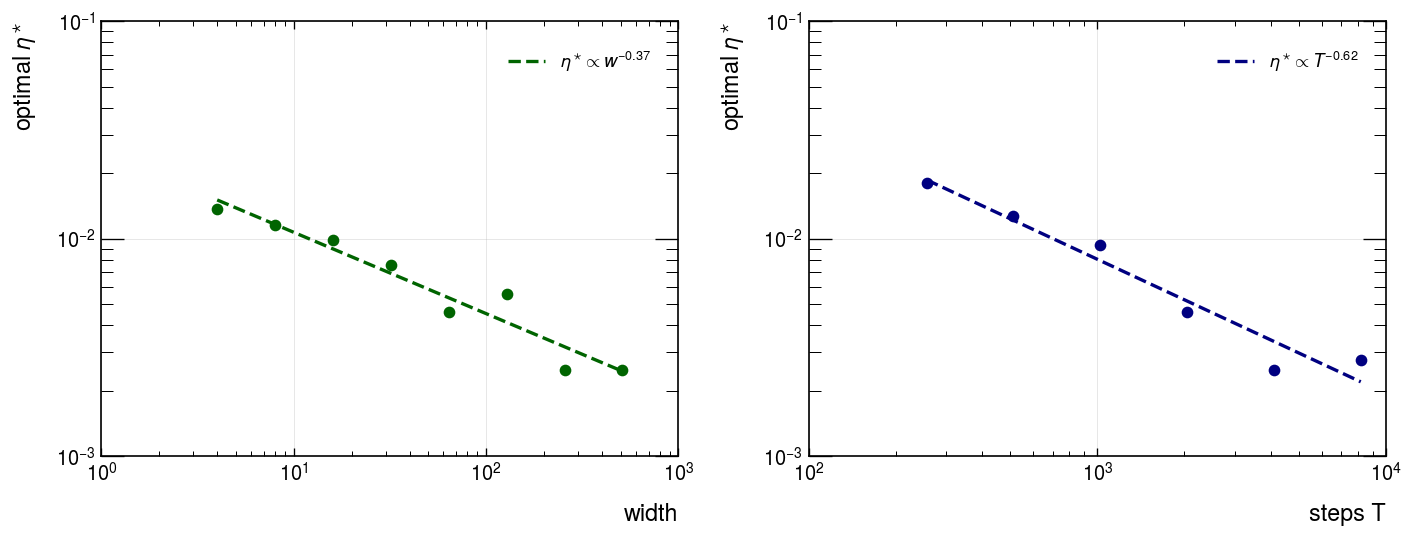

In [3]:
law = fit_law_from_points(study["widths"], study["eta_width"],
                          study["Tsteps"], study["eta_T"],
                          w_ref=study["w_ref"], T_ref=study["T_ref"])
print(f"eta*(w,T) = {law['eta_ref']} * (w/{law['w_ref']})^{law['c_w']} "
      f"* (T/{law['T_ref']})^{law['c_T']}")
Image(filename=str(FIGDIR / "hp_study_cosine.png"))

## What re-tuning buys: the "don't tune" ablation

To make the cost of *not* tuning concrete, [`run_lr_ablation.py`](../scripts/run_lr_ablation.py)
(at $L{=}2$) holds **one fixed LR**, the value optimal at the small end of an axis, and scales
the other axis, against the fully per-cell-tuned baseline:

- **Left, scale $D$ at fixed width $w{=}64$.** An LR tuned at small $D$ is too *hot* once $D$ is
  large ($\eta^\star$ falls with the horizon), so the fixed-LR loss stops improving and eventually
  **rises**.
- **Right, scale $N$ at fixed $D$.** An LR tuned at small $N$ is too hot once the net is wide
  (the μP shift), so again the fixed-LR loss flattens and **turns up** for the biggest models.

In both, the per-cell-tuned curve keeps descending; the gap (in reducible loss $L-E$) is the
tuning tax, and it *grows* with scale. That is why reading a scaling exponent off a mis-tuned
grid biases it, and can prevent scaling from showing up at all.

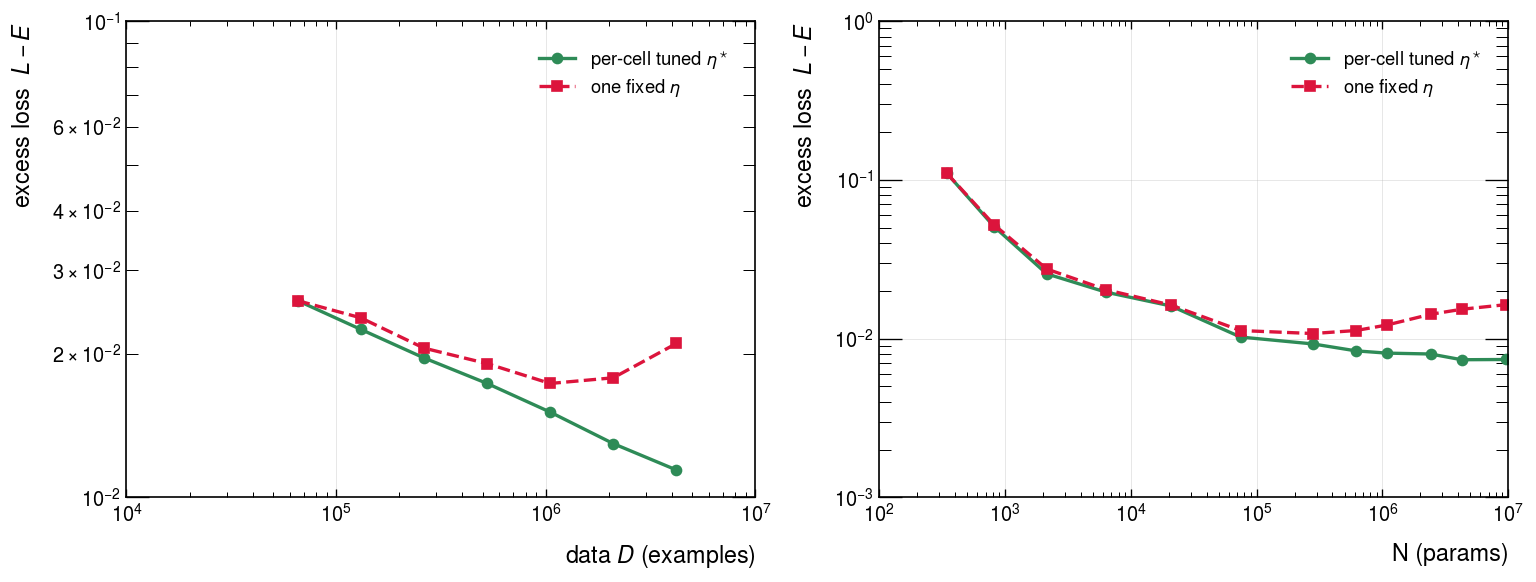

In [4]:
Image(filename=str(FIGDIR / "lr_ablation.png"))

**Two caveats.**

- **Batch size is held fixed** at $b=256$ for simplicity. In principle $b$ is a hyperparameter
  too, one that should be **tuned _and scaled_** jointly with $\eta$ (the optimal batch grows
  with the horizon, $b^\star\propto\sqrt T$). We fix it and let the $T$-law absorb the horizon
  dependence at this one batch size.
- **This is the single-pass / growing-horizon regime**, each example is seen once and $T$ grows
  with $D$. It is *not* the same as replaying a *limited* dataset for many epochs, where you
  overfit the noise and see double descent, that regime lives in
  [`04_double_descent.ipynb`](04_double_descent.ipynb).

**Takeaway.** One law $\eta^\star(w,T)$, calibrated once, sets the learning rate for every cell in
the grid. **[Notebook 03](03_scaling_analysis.ipynb)** runs that grid and extracts the
compute-optimal frontier three ways.